In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

In [2]:
X, y = make_moons(n_samples=400, noise=0.2, random_state=42)
y = y.reshape(-1, 1) # shape (400, 1)

In [3]:
# Normalise inputs so gradient descent stays stable
X = (X - X.mean(axis=0)) / X.std(axis=0)

In [4]:
# Activations and derivatives
def relu(z):
    return np.maximum(0, z)
 
def relu_deriv(z):
    return (z > 0).astype(float)
 
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
 
def sigmoid_deriv(z):
    s = sigmoid(z)
    return s * (1 - s)

In [5]:
def init_weights(layer_dims):
    """
    layer_dims: list of ints, e.g. [2, 4, 4, 1]
    Returns dict of W1,b1, W2,b2, W3,b3
    """
    params = {}
    for l in range(1, len(layer_dims)):
        n_in  = layer_dims[l - 1]
        n_out = layer_dims[l]
        params[f"W{l}"] = np.random.randn(n_in, n_out) * np.sqrt(2.0 / n_in)
        params[f"b{l}"] = np.zeros((1, n_out))
    return params


In [6]:
def forward(X, params):
    """
    Returns the final prediction and a cache of intermediate values needed for backprop
    """
    cache = {}
    A = X
    n_layers = len(params) // 2 # number of weight matrices
 
    for l in range(1, n_layers + 1):
        W = params[f"W{l}"]
        b = params[f"b{l}"]
 
        Z = A @ W + b        # linear combination:  Z = A·W + b
        cache[f"A{l-1}"] = A # save input to this layer
        cache[f"Z{l}"]   = Z # save pre-activation
 
        # Last layer: sigmoid (binary output)
        # Hidden layers: ReLU
        A = sigmoid(Z) if l == n_layers else relu(Z)
 
    return A, cache

In [7]:
def compute_loss(y_pred, y_true):
    m = y_true.shape[0]
    eps = 1e-9 # prevent log(0)
    loss = -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))
    return loss

In [8]:
def backward(y_pred, y_true, params, cache):
    """
    Computes gradients dW and db for every layer via chain rule
    Returns a dict of gradients
    """
    m = y_true.shape[0]
    grads = {}
    n_layers = len(params) // 2
 
    # Gradient of BCE loss w.r.t. the sigmoid output
    dA = -(y_true / (y_pred + 1e-9) - (1 - y_true) / (1 - y_pred + 1e-9))
 
    for l in range(n_layers, 0, -1):
        Z  = cache[f"Z{l}"]
        A_prev = cache[f"A{l-1}"]
        W  = params[f"W{l}"]
 
        # Chain rule: dZ = dA * activation'(Z)
        if l == n_layers:
            dZ = dA * sigmoid_deriv(Z)
        else:
            dZ = dA * relu_deriv(Z)
 
        # Gradient of loss w.r.t. weights and biases
        grads[f"dW{l}"] = (A_prev.T @ dZ) / m
        grads[f"db{l}"] = np.mean(dZ, axis=0, keepdims=True)
 
        # Pass gradient back through this layer's weights
        dA = dZ @ W.T
 
    return grads


In [9]:
def update_params(params, grads, lr):
    n_layers = len(params) // 2
    for l in range(1, n_layers + 1):
        params[f"W{l}"] -= lr * grads[f"dW{l}"]
        params[f"b{l}"] -= lr * grads[f"db{l}"]
    return params


In [10]:
np.random.seed(42)
params = init_weights([2, 4, 4, 1])
 
learning_rate = 0.1
epochs = 2000
loss_history = []
 
for epoch in range(epochs):
    y_pred, cache = forward(X, params)
    loss = compute_loss(y_pred, y)
    grads = backward(y_pred, y, params, cache)
    params = update_params(params, grads, learning_rate)
    loss_history.append(loss)
 
    if epoch % 200 == 0:
        acc = np.mean((y_pred > 0.5) == y)
        print(f"Epoch {epoch:4d} | Loss: {loss:.4f} | Accuracy: {acc:.2%}")


Epoch    0 | Loss: 0.7383 | Accuracy: 24.75%
Epoch  200 | Loss: 0.4028 | Accuracy: 83.50%
Epoch  400 | Loss: 0.2887 | Accuracy: 84.50%
Epoch  600 | Loss: 0.2350 | Accuracy: 88.75%
Epoch  800 | Loss: 0.1767 | Accuracy: 94.25%
Epoch 1000 | Loss: 0.1289 | Accuracy: 96.50%
Epoch 1200 | Loss: 0.0994 | Accuracy: 97.00%
Epoch 1400 | Loss: 0.0821 | Accuracy: 97.00%
Epoch 1600 | Loss: 0.0765 | Accuracy: 97.75%
Epoch 1800 | Loss: 0.0738 | Accuracy: 97.50%


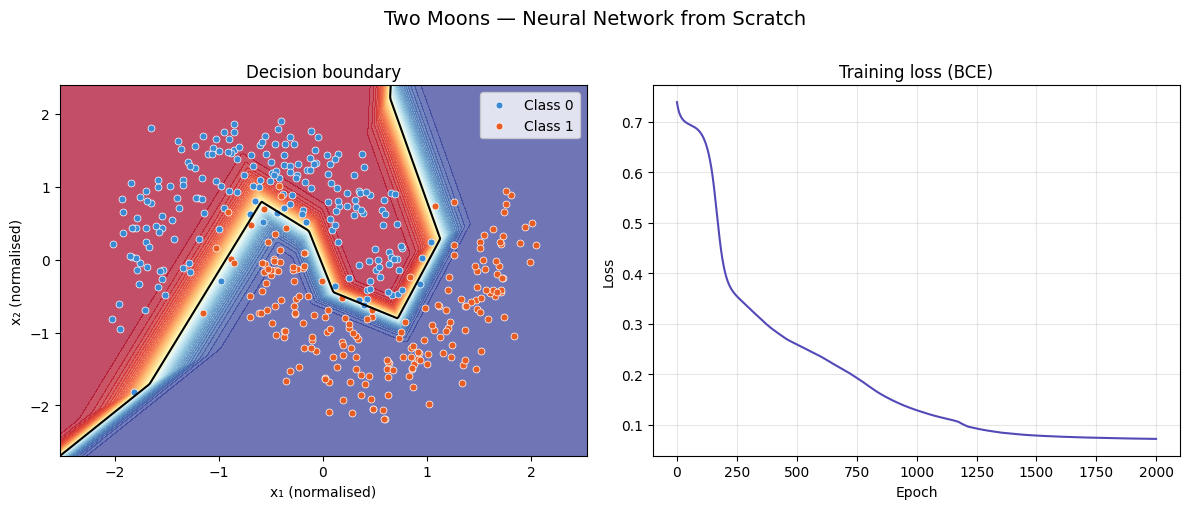


Plot saved to out
Final accuracy: 97.50%


In [11]:
# VISUALISATION
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Two Moons — Neural Network from Scratch", fontsize=14, y=1.01)
 
# — Decision boundary —
ax = axes[0]
h = 0.02
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]
Z_pred, _ = forward(grid, params)
Z_pred = Z_pred.reshape(xx.shape)
 
ax.contourf(xx, yy, Z_pred, levels=50, cmap="RdYlBu", alpha=0.7)
ax.contour(xx, yy, Z_pred, levels=[0.5], colors="black", linewidths=1.5)
ax.scatter(X[y.ravel() == 0, 0], X[y.ravel() == 0, 1],
           c="#3B8BD4", edgecolors="white", s=25, linewidths=0.5, label="Class 0")
ax.scatter(X[y.ravel() == 1, 0], X[y.ravel() == 1, 1],
           c="#E85D24", edgecolors="white", s=25, linewidths=0.5, label="Class 1")
ax.set_title("Decision boundary")
ax.set_xlabel("x₁ (normalised)")
ax.set_ylabel("x₂ (normalised)")
ax.legend(loc="upper right")
 
# — Training loss curve —
ax2 = axes[1]
ax2.plot(loss_history, color="#534AB7", linewidth=1.5)
ax2.set_title("Training loss (BCE)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.grid(True, alpha=0.3)
 
plt.tight_layout()
# Save output to disk
from os import makedirs
makedirs("out", exist_ok=True)
from datetime import datetime
plt.savefig(f"./out/result_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved to out")
 
final_pred, _ = forward(X, params)
final_acc = np.mean((final_pred > 0.5) == y)
print(f"Final accuracy: {final_acc:.2%}")